In [22]:
# ============================================
# 0) Imports
# ============================================
import albumentations as A
import cv2
import numpy as np
import os
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import Sequence
import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns



print(tf.__version__)
print("All imports work correctly ✅")
print(A.__version__)

2.18.0
All imports work correctly ✅
2.0.8


In [23]:
#  Preprocessing Function
def preprocess_image(img, target_size=(224, 224)):
    if len(img.shape) == 2:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    elif img.shape[2] == 1:
        img = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)

    img = cv2.resize(img, target_size)

    kernel = np.array([[0,-1,0], [-1,5,-1], [0,-1,0]]) #sharpening
    img = cv2.filter2D(img, -1, kernel)

    # img = img / 255.
    img = img.astype(np.float32) / 255.0
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = (img - mean) / std
    return img


#  Albumentations Augmentation Pipeline
def get_augmentation_pipeline(target_size=(224, 224)):
    transform = A.Compose([
        A.HorizontalFlip(p=0.5),
        # A.Rotate(limit=10, border_mode=cv2.BORDER_REFLECT, p=0.5),
        A.RandomResizedCrop(size=target_size, scale=(0.8, 1.0), ratio=(0.9, 1.1), p=0.5),
        A.ShiftScaleRotate(
            shift_limit=0.1,
            scale_limit=0.1,
            rotate_limit=10,
            border_mode=cv2.BORDER_REFLECT,
            p=0.5
        ),
        A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.5),
        
        A.CoarseDropout(
            max_holes=4,
            max_height=8,
            max_width=8,
            fill_value="random",  
            p=0.3
        )
    ])
    return transform



# 3) Load Images from Folder (Ignore Mask folders)
def get_images_from_folder(base_path):
    images_list = []
    for root, dirs, files in os.walk(base_path):
        if 'Mask' in root.split(os.sep):
            continue
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg')):
                images_list.append(os.path.join(root, file))
    return images_list


# Custom Data Generator

class ImageDataGeneratorSequence(Sequence):
    def __init__(self, food_paths, fruit_paths, batch_size=32, augment=False,
                 target_size=(224, 224), shuffle=True, target_count_per_class=None):
        self.food_paths  = food_paths
        self.fruit_paths = fruit_paths
        self.batch_size  = batch_size
        self.augment     = augment
        self.target_size = target_size
        self.shuffle     = shuffle
        self.target_count_per_class = target_count_per_class
        self.transform = get_augmentation_pipeline(self.target_size) if self.augment else None


        if self.augment and self.target_count_per_class:
            self.food_paths = self._oversample(self.food_paths, self.target_count_per_class)
            self.fruit_paths = self._oversample(self.fruit_paths, self.target_count_per_class)

        self.all_paths = self.food_paths + self.fruit_paths
        self.labels = np.array([0]*len(self.food_paths) + [1]*len(self.fruit_paths))
        self.on_epoch_end()

    def __len__(self):
        return int(np.ceil(len(self.all_paths) / self.batch_size))

    def __getitem__(self, idx):
        batch_paths = self.all_paths[idx*self.batch_size : (idx+1)*self.batch_size]
        batch_labels = self.labels[idx*self.batch_size : (idx+1)*self.batch_size]
        batch_images = []
        batch_labels_clean = []

        for path, label in zip(batch_paths, batch_labels):
            img = cv2.imread(path)
            if img is None:
                print(f"⚠️ Warning: Could not load image {path}")
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            if self.augment:

                img = self.transform(image=img)["image"]

            img = preprocess_image(img, self.target_size)
            batch_images.append(img)
            batch_labels_clean.append(label)

        return np.array(batch_images), np.array(batch_labels_clean)

    def on_epoch_end(self):
        if self.shuffle:
            idxs = np.arange(len(self.all_paths))
            np.random.shuffle(idxs)
            self.all_paths = [self.all_paths[i] for i in idxs]
            self.labels = self.labels[idxs]

    # Utility functions
    def _oversample(self, paths, target_count):
        if len(paths) >= target_count:
            return paths[:target_count]
        extra = []
        while len(paths) + len(extra) < target_count:
            extra += paths
        return paths + extra[:target_count - len(paths)]

#  PATHS
food_train_path = r"/kaggle/input/food-vs-fruit-dataset/Project Data/Food/Train"
food_test_path  = r"/kaggle/input/food-vs-fruit-dataset/Project Data/Food/Validation"
fruit_train_path = r"/kaggle/input/food-vs-fruit-dataset/Project Data/Fruit/Train"
fruit_test_path  = r"/kaggle/input/food-vs-fruit-dataset/Project Data/Fruit/Validation"


#  Load Images + Split
food_train_images_all = get_images_from_folder(food_train_path)
food_test_images = get_images_from_folder(food_test_path)
fruit_train_images_all = get_images_from_folder(fruit_train_path)
fruit_test_images = get_images_from_folder(fruit_test_path)

food_train_images, food_val_images = train_test_split(food_train_images_all, test_size=0.3, random_state=42)
fruit_train_images, fruit_val_images = train_test_split(fruit_train_images_all, test_size=0.3, random_state=42)

print("before oversampling:")
print(f"→ Food - Train: {len(food_train_images)}")
print(f"→ Fruit - Train: {len(fruit_train_images)}")
print(f"→ Food - Val: {len(food_val_images)}")
print(f"→ Fruit - Val: {len(fruit_val_images)}")
print(f"→ Food - Test: {len(food_test_images)}")
print(f"→ Fruit - Test: {len(fruit_test_images)}")
print("-" * 50)

#  Generators
batch_size = 32

train_gen = ImageDataGeneratorSequence(food_train_images, fruit_train_images, batch_size=batch_size, augment=True,target_count_per_class=2000)
val_gen   = ImageDataGeneratorSequence(food_val_images, fruit_val_images, batch_size=batch_size, augment=False,shuffle=False)
test_gen  = ImageDataGeneratorSequence(food_test_images, fruit_test_images, batch_size=batch_size, augment=False, shuffle=False)

print("📊 Number of training paths per class:")
print(f"Food paths: {len(train_gen.food_paths)}")
print(f"Fruit paths: {len(train_gen.fruit_paths)}")
print(f"Total paths in generator: {len(train_gen.all_paths)}")

print("data managed")

before oversampling:
→ Food - Train: 1776
→ Fruit - Train: 1231
→ Food - Val: 762
→ Fruit - Val: 528
→ Food - Test: 261
→ Fruit - Test: 150
--------------------------------------------------
📊 Number of training paths per class:
Food paths: 2000
Fruit paths: 2000
Total paths in generator: 4000
data managed


/tmp/ipykernel_47/915544586.py:40: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


In [24]:
def test_model(model, test_generator, threshold=0.5, class_names=["Food", "Fruit"]):

    if hasattr(test_generator, 'shuffle') and test_generator.shuffle:
        print(" Warning: test_generator.shuffle=True may cause label mismatch!")

    print(" Predicting on test set...")
    y_pred_prob = model.predict(test_generator, verbose=1)
    y_pred = (y_pred_prob > threshold).astype(int).flatten()

    assert len(y_pred) == len(test_generator.all_paths), \
        f"Prediction count mismatch: {len(y_pred)} vs {len(test_generator.all_paths)}"
    
    y_true = test_generator.labels

    acc = accuracy_score(y_true, y_pred)
    print(f"\n Test Accuracy: {acc*100:.2f}%")

    print("\n📌 Classification Report:")
    report = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=[f"Pred {name}" for name in class_names],
        yticklabels=[f"True {name}" for name in class_names]
    )
    plt.title("Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return {
        "accuracy": acc,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_pred_prob": y_pred_prob,
        "classification_report": report,
        "confusion_matrix": cm
    }



--- Training Head (Frozen InceptionResNetV2)...
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 99s 602ms/step - accuracy: 0.5730 - loss: 0.8325 - val_accuracy: 0.9116 - val_loss: 0.3286 - learning_rate: 1.0000e-04
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 443ms/step - accuracy: 0.8088 - loss: 0.4084 - val_accuracy: 0.9574 - val_loss: 0.1861 - learning_rate: 1.0000e-04
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 56s 446ms/step - accuracy: 0.9019 - loss: 0.2641 - val_accuracy: 0.9760 - val_loss: 0.1296 - learning_rate: 1.0000e-04
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 459ms/step - accuracy: 0.9380 - loss: 0.1863 - val_accuracy: 0.9806 - val_loss: 0.0995 - learning_rate: 1.0000e-04
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 59s 471ms/step - accuracy: 0.9476 - loss: 0.1713 - val_accuracy: 0.9829 - val_loss: 0.0823 - learning_rate: 1.0000e-04
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 60s 478ms/step - accuracy: 0.9523 - loss: 0.1425 - val_accuracy: 0.9853 - val_loss: 0.0694 - learning_rate: 1.0000e-0

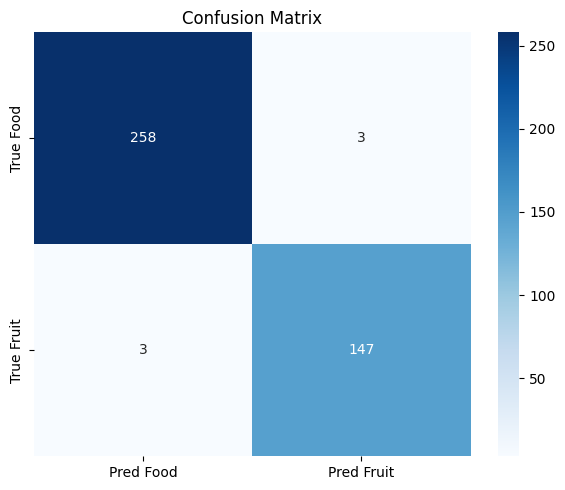

---  model saved successfully!


In [25]:
#  Build Model with InceptionResNetV2
from tensorflow.keras.applications import InceptionResNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Callbacks
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    mode='max',
    min_delta=0.001,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_accuracy',
    factor=0.5,
    patience=3,
    mode='max',
    min_lr=1e-7,
    verbose=1
)

# Base model
base_model = InceptionResNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

# Head
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)  
outputs = Dense(1, activation="sigmoid")(x)

model = Model(inputs, outputs)

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Train Head (Frozen backbone)
print("--- Training Head (Frozen InceptionResNetV2)...")
history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)
#  Evaluate on Test Set
print("Trained Head Model Test Accuracy: ")
results = test_model(model, test_gen)

# Save Final Model
acc=results["accuracy"]

model.save(f"Model_inceptionresnetv2_acc_{acc:.4f}.keras")
print("---  model saved successfully!")

-- Fine-tuning last 50 layers...
Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 107s 595ms/step - accuracy: 0.9138 - loss: 0.3155 - val_accuracy: 0.9837 - val_loss: 0.1196 - learning_rate: 1.0000e-06
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 60s 478ms/step - accuracy: 0.9544 - loss: 0.2502 - val_accuracy: 0.9829 - val_loss: 0.1442 - learning_rate: 1.0000e-06
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 455ms/step - accuracy: 0.9590 - loss: 0.2053 - val_accuracy: 0.9876 - val_loss: 0.1296 - learning_rate: 1.0000e-06
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 58s 464ms/step - accuracy: 0.9678 - loss: 0.1723 - val_accuracy: 0.9891 - val_loss: 0.1076 - learning_rate: 1.0000e-06
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 57s 452ms/step - accuracy: 0.9707 - loss: 0.1483 - val_accuracy: 0.9899 - val_loss: 0.0915 - learning_rate: 1.0000e-06
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 59s 467ms/step - accuracy: 0.9721 - loss: 0.1373 - val_accuracy: 0.9907 - val_loss: 0.0807 - learning_rate: 1.0000e-06
Epoch 7/10
1

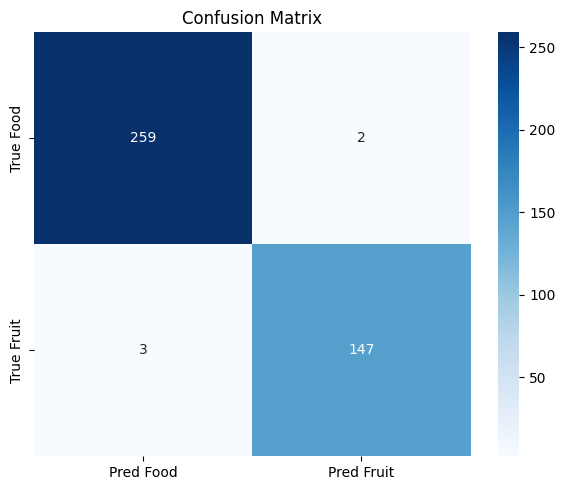

 Final model saved successfully!


In [26]:
#  Fine-tune last layers
base_model.trainable = True
# Freeze all but last 50 layers 
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=Adam(learning_rate=1e-6),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("-- Fine-tuning last 50 layers...")
history_fine = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# Evaluate on Test Set
print("Fine-tuning Model Test Accuracy: ")

results = test_model(model, test_gen)

#  Save Final Model
acc=results["accuracy"]

model.save(f"Final_model_inceptionresnetv2_acc_{acc:.4f}.keras")
print(" Final model saved successfully!")